# Parcial: Curso Análisis Predictivo de Series Temporales

## Posgrado de Big Data

## Universidad ORT Uruguay

### Curso 2025 - 15/7/2025.

## Estudiante: (completar)

In [46]:
#### BLOQUE DE IMPORTS STANDAR DE LA MATERIA. ES A FINES DE SIMPLICIDAD PARACTICA PARA EL PARACIAL####


import warnings
with warnings.catch_warnings(action="ignore"):
    import astsadata as astsa
    
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import scipy.stats as stats
import scipy as sp
import statsmodels.api as sm
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.graphics.api import qqplot


from statsmodels.formula.api import ols
from statsmodels.tsa.api import ARIMA, SARIMAX
from arch import arch_model
from statsmodels.tsa.api import UnobservedComponents

import tensorflow as tf
import keras


## Ajusto tamaño de figuras
plt.rcParams['figure.figsize'] = [15,5]
plt.rcParams['axes.grid'] = True
plt.rcParams['figure.constrained_layout.use'] = True

#### Funciones útiles

In [2]:
from statsmodels.graphics.tsaplots import plot_acf,plot_pacf
from statsmodels.formula.api import ols

def ccf(x, y, max_lag, ax=None, **kwargs):
    lags = np.arange(-max_lag, max_lag + 1)

    backwards = sm.tsa.ccf(x[::-1], y[::-1], adjusted=False)[max_lag::-1]
    forwards = sm.tsa.ccf(x, y, adjusted=False)[:max_lag + 1]
    ccf = np.r_[backwards[:-1], forwards]
    ylabel = "CCF"

    if ax is None:
        ax = plt.gca()
    
    ax.stem(lags, ccf, basefmt="k")
    ax.axvline(0, color="black", linestyle="--", linewidth=1)
    conf_level = 1.96 / np.sqrt(x.shape[0])
    ax.fill_between(lags,conf_level,-conf_level,alpha=0.25)
    ax.set_xlabel("LAG")
    ax.set_ylabel(ylabel)

    
    return ax

def periodogram(x,sampling_frequency=1):

    """Función que calcula el periodograma y grafica.
    
    Parameters
    ----------
        x : array_like, data.
        sampling_frequency: frecuencia de muestreo de la serie, para graficar.
    """

    n = x.size
    P = 4/n**2 * np.abs(np.fft.fft(x))**2
    P = P[0:round(n/2)]
    f = np.arange(0,round(n/2))/n * sampling_frequency
    plt.plot(f,P);
    plt.xlabel("Frequency")
    plt.ylabel("Power")


def spectrum(x,sampling_frequency=1, nfreq=10):

    """Función que calcula las componentes más relevantes del periodograma.
    
    Parameters
    ----------
        x : array_like, data.
        sampling_frequency: frecuencia de muestreo de la serie, para graficar.
    """

    n = x.size
    nfreq = np.minimum(nfreq,round(n/2)) #corto nfreq si la serie es muy corta!
    P = 4/n**2 * np.abs(np.fft.fft(x))**2
    P = P[0:round(n/2)]
    f = np.arange(0,round(n/2))/n * sampling_frequency
    index = np.argsort(P)[::-1] #ordeno P decreciente
    return pd.DataFrame({"Frecuencia" : f[index[0:nfreq]],"Potencia" : P[index[0:nfreq]]})

In [77]:
def plot_fits(fits, mses, labels):
    """Función que grafica la serie original junto con los ajustes.
    
    Parameters
    ----------
        x : array_like, data.
        fits: lista de arrays con los ajustes a graficar.
        labels: lista de strings con las etiquetas de cada ajuste.
    """
    nrows = 4
    ncols = len(fits)
    figs, axs = plt.subplots(nrows, ncols, figsize=(6 * ncols, 16), squeeze=False)
    i = 0
    for fit, label, mse in zip(fits, labels, mses):
        fit.resid.plot(ax=axs[0, i], label="Residuos")
        axs[0, i].title.set_text(f"Residuos del ajuste {label}, \n RMSE = {round(mse, 4)}")
        
        plot_acf(fit.resid, ax=axs[1, i], bartlett_confint=False)
        axs[1, i].title.set_text(f"Autocorrelación (ACF) residuos \n {label}")
        
        plot_pacf(fit.resid, ax=axs[2, i])
        axs[2, i].title.set_text(f"Autocorrelación Parcial (PACF) residuos \n {label}")
        
        qqplot(fit.resid, line="s", ax=axs[3, i])
        axs[3, i].title.set_text(f"QQ Plot residuos \n {label}")
        i += 1
    plt.tight_layout()
    plt.show()

## Ejercicio 1

Se considera la serie `tmort` de la biblioteca `astsa`, que registra la mortalidad global en Los Angeles con frecuencia semanal que se grafica abajo.

1. Realizar un ajuste de tendencia lineal para la serie. Discutir el resultado.
2. Agregar un término de tendencia cuadrática $x = \beta_0 + \beta_1 t + \beta_2 t^2 + w_t$ y discutir si mejora respecto al anterior.
3. Realizar un periodograma de los residuos para encontrar componentes estacionales (por ej. anuales).
4. Incluir en la regresión tanto los términos de tendencia como estacionales que considere adecuados y realizar el ajuste.
5. Discutir los residuos obtenidos. ¿Queda información por extraer? (No se pide realizar más ajustes)

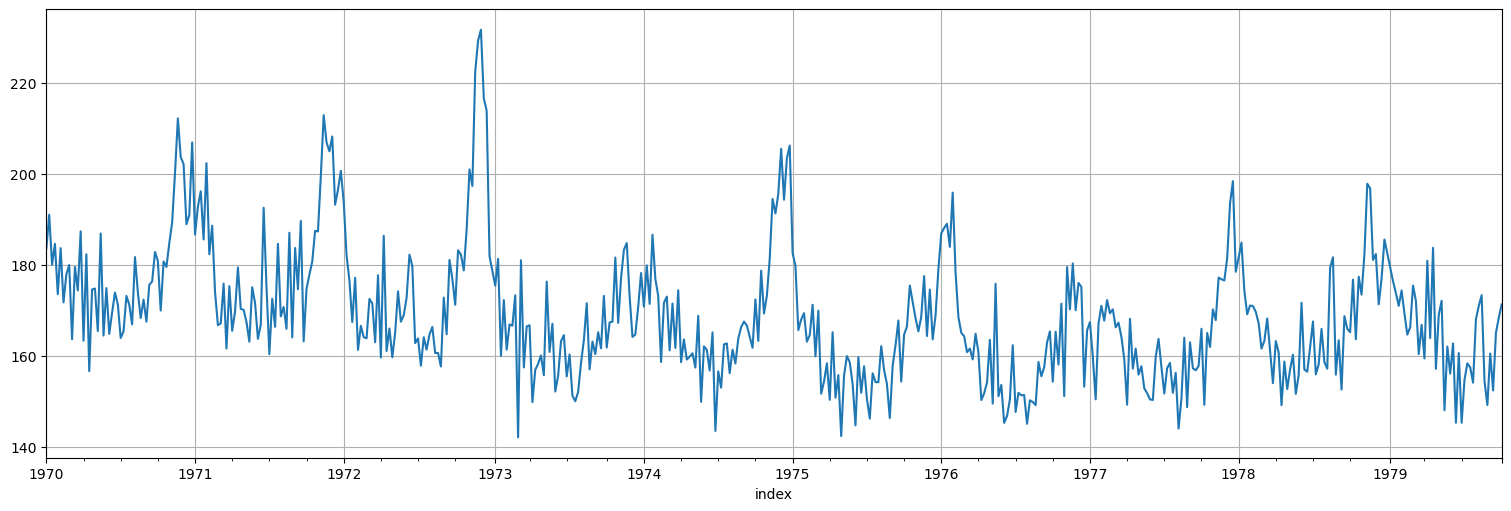

In [4]:
x = astsa.lap.tmort
x.plot();

In [9]:
x.head()

index
1969-12-29/1970-01-04    183.63
1970-01-05/1970-01-11    191.05
1970-01-12/1970-01-18    180.09
1970-01-19/1970-01-25    184.67
1970-01-26/1970-02-01    173.60
Freq: W-SUN, Name: tmort, dtype: float64

#### 1

<Axes: xlabel='index'>

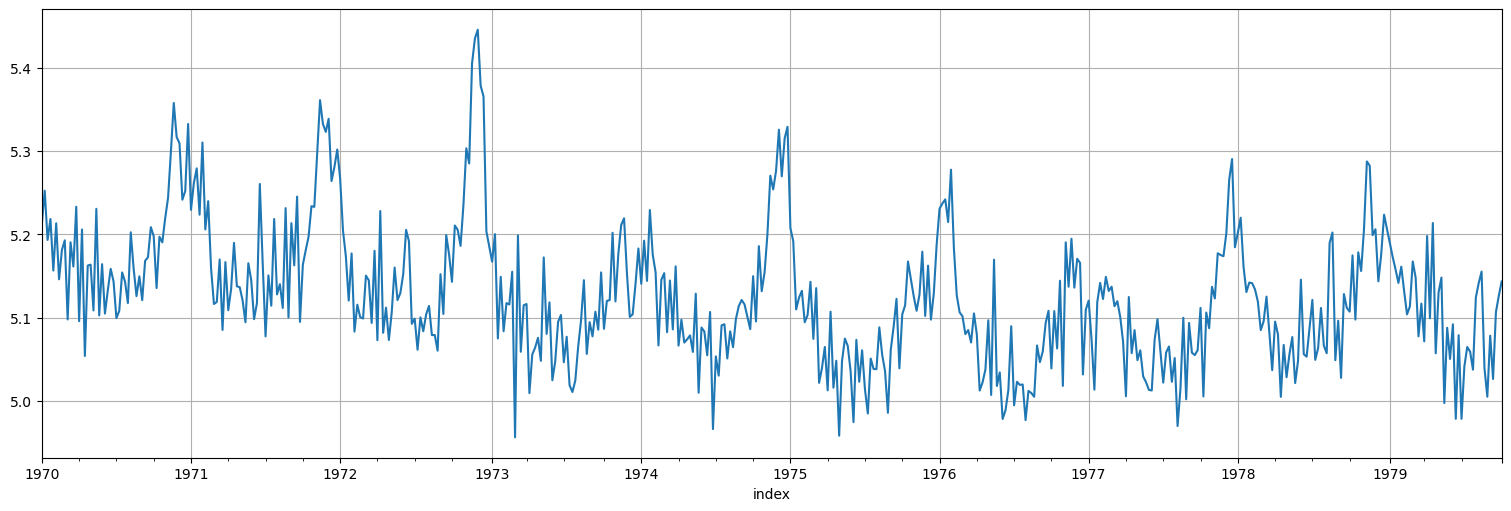

In [19]:
log_x = np.log(x)
log_x.plot()

In [23]:
time = pd.Series(np.arange(len(log_x)),index=log_x.index)

x_reg= pd.concat([log_x, time], axis=1).dropna()

x_reg.columns = ["tmort", "time"]

fit_l = ols("tmort ~ time", data=x_reg).fit()
l_mse=np.sqrt(fit_l.mse_resid)
print(f"RMSE de los residuos: {l_mse}")
fit_l.summary()

RMSE de los residuos: 0.07599487161179573


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  tmort   R-squared:                       0.125
Model:                            OLS   Adj. R-squared:                  0.124
Method:                 Least Squares   F-statistic:                     72.59
Date:                Mon, 13 Jul 2026   Prob (F-statistic):           1.84e-16
Time:                        06:56:14   Log-Likelihood:                 589.34
No. Observations:                 508   AIC:                            -1175.
Df Residuals:                     506   BIC:                            -1166.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      5.1765      0.007    768.765      0.000       5.163       5.190
time          -0.0002    2.3e-05     -8.520      0.000      -0.000      -0.000
==============================================================================
Omnibus:                       49.937   Durbin-Watson:                   0.661
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               64.326
Skew:                           0.766   Prob(JB):                     1.08e-14
Kurtosis:                       3.833   Cond. No.                         585.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

/var/folders/zc/xfn7bz2d1wj_vv2lvqvmndcr0000gp/T/ipykernel_23787/3390279225.py:27: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


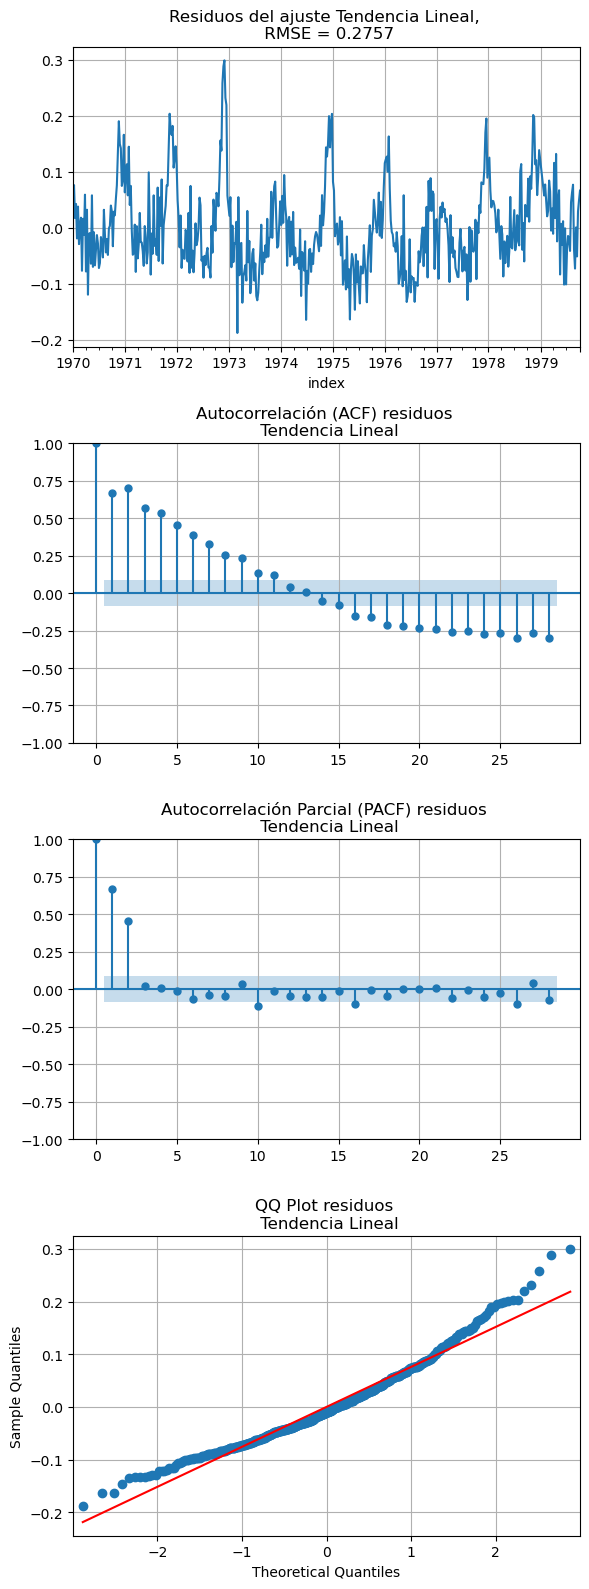

In [26]:
plot_fits([fit_l],[l_mse],["Tendencia Lineal"])


La curva parece tener una tendencia lineal hacia abajo. 

Se puede ver que la varible tiempo es siginificativa, pero los resuduos aun estan legejos de ser algo gaussiano



#### 2

In [ ]:
x_reg= pd.concat([x_reg,time**2], axis=1).dropna()

x_reg.columns = ["tmort", "time", "time2"]

In [31]:
fit_quad = ols("tmort ~ time + time2", data=x_reg).fit()
quad_mse=np.sqrt(fit_quad.mse_resid)
print(f"RMSE de los residuos: {quad_mse}")
fit_quad.summary()

RMSE de los residuos: 0.07465499994945954


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  tmort   R-squared:                       0.158
Model:                            OLS   Adj. R-squared:                  0.154
Method:                 Least Squares   F-statistic:                     47.27
Date:                Mon, 13 Jul 2026   Prob (F-statistic):           1.52e-19
Time:                        07:00:23   Log-Likelihood:                 598.88
No. Observations:                 508   AIC:                            -1192.
Df Residuals:                     505   BIC:                            -1179.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      5.2089      0.010    526.261      0.000       5.189       5.228
time          -0.0006   9.02e-05     -6.428      0.000      -0.001      -0.000
time2        7.57e-07   1.72e-07      4.396      0.000    4.19e-07     1.1e-06
==============================================================================
Omnibus:                       67.101   Durbin-Watson:                   0.687
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               98.008
Skew:                           0.893   Prob(JB):                     5.22e-22
Kurtosis:                       4.201   Cond. No.                     3.44e+05
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 3.44e+05. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

Lo que veo, sin motrar los resuletados es que ya el tiempo no mejora, puesto que tanto time como time2 nos son variables significativas para tmort

/var/folders/zc/xfn7bz2d1wj_vv2lvqvmndcr0000gp/T/ipykernel_23787/831404204.py:27: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


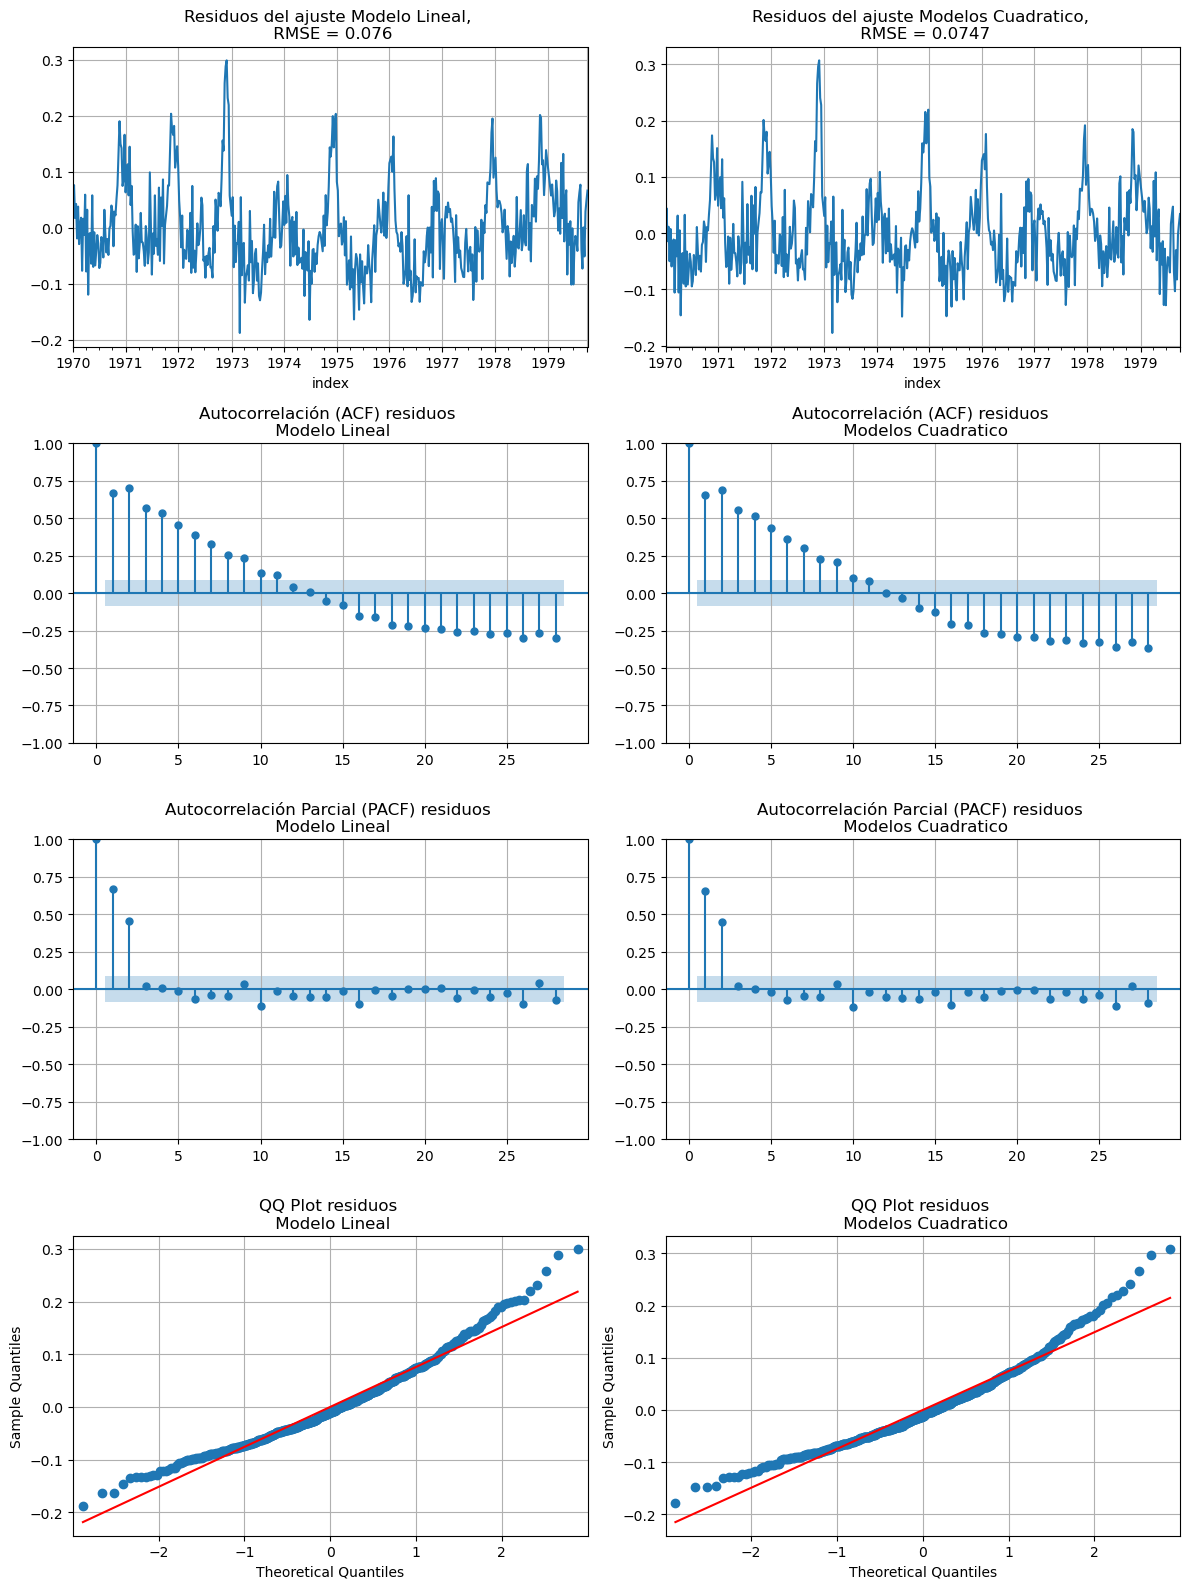

In [78]:
plot_fits([fit_l,fit_quad],[l_mse,quad_mse],["Modelo Lineal","Modelos Cuadratico"])

Lo que se ve es que, no parecen cambiar mucho las metricas en general, pero los residuos tenian una pequeña panza en el centro de la serie que se quita al hacer el modelo cuadratico. 

Respecto al MSE no prece mejorar mucho, lo mismo para IAC y BIC, se mantienen en valores similares

#### 3.

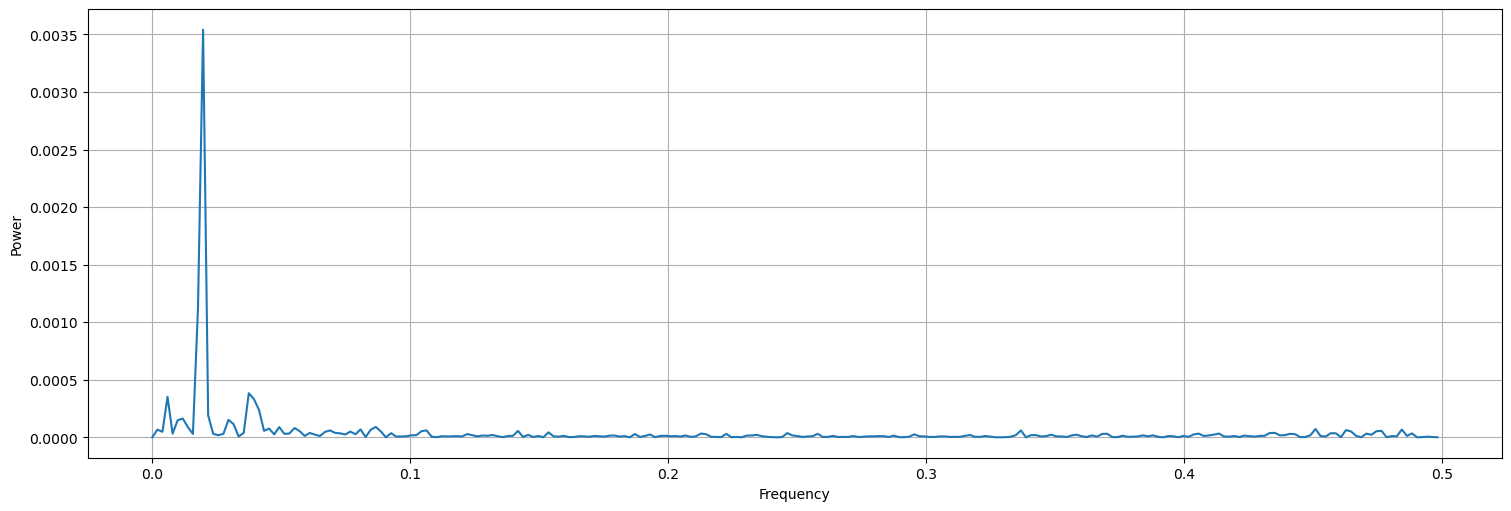

In [33]:
quad_resid= fit_quad.resid
periodogram(quad_resid)

In [34]:
spectrum(quad_resid)

,Frecuencia,Potencia
0,0.019685,0.003541
1,0.017717,0.001128
2,0.037402,0.000383
3,0.005906,0.000353
4,0.039370,0.000333
5,0.041339,0.000240
6,0.021654,0.000191
7,0.011811,0.000163
8,0.029528,0.000152
9,0.009843,0.000149


In [41]:
1/0.019685

50.8001016002032

### 4.

In [47]:
f =0.019685
fit_freq = ols(formula="tmort ~ time +time2 + np.cos(2*np.pi*f*time) + np.sin(2*np.pi*f*time)", data=x_reg).fit()
freq_mse=np.sqrt(fit_freq.mse_resid)
print(f"RMSE de los residuos: {freq_mse}")
fit_freq.summary()

RMSE de los residuos: 0.061687821294690755


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  tmort   R-squared:                       0.427
Model:                            OLS   Adj. R-squared:                  0.423
Method:                 Least Squares   F-statistic:                     93.77
Date:                Mon, 13 Jul 2026   Prob (F-statistic):           1.51e-59
Time:                        07:18:35   Log-Likelihood:                 696.81
No. Observations:                 508   AIC:                            -1384.
Df Residuals:                     503   BIC:                            -1362.
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
================================================================================================
                                   coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------------
Intercept                        5.2059      0.008    635.851      0.000       5.190       5.222
time                            -0.0006   7.45e-05     -7.531      0.000      -0.001      -0.000
time2                         7.376e-07   1.42e-07      5.183      0.000    4.58e-07    1.02e-06
np.cos(2 * np.pi * f * time)     0.0564      0.004     14.561      0.000       0.049       0.064
np.sin(2 * np.pi * f * time)     0.0193      0.004      4.965      0.000       0.012       0.027
==============================================================================
Omnibus:                       37.564   Durbin-Watson:                   1.002
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               58.915
Skew:                           0.526   Prob(JB):                     1.61e-13
Kurtosis:                       4.295   Cond. No.                     3.44e+05
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 3.44e+05. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

/var/folders/zc/xfn7bz2d1wj_vv2lvqvmndcr0000gp/T/ipykernel_23787/831404204.py:27: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


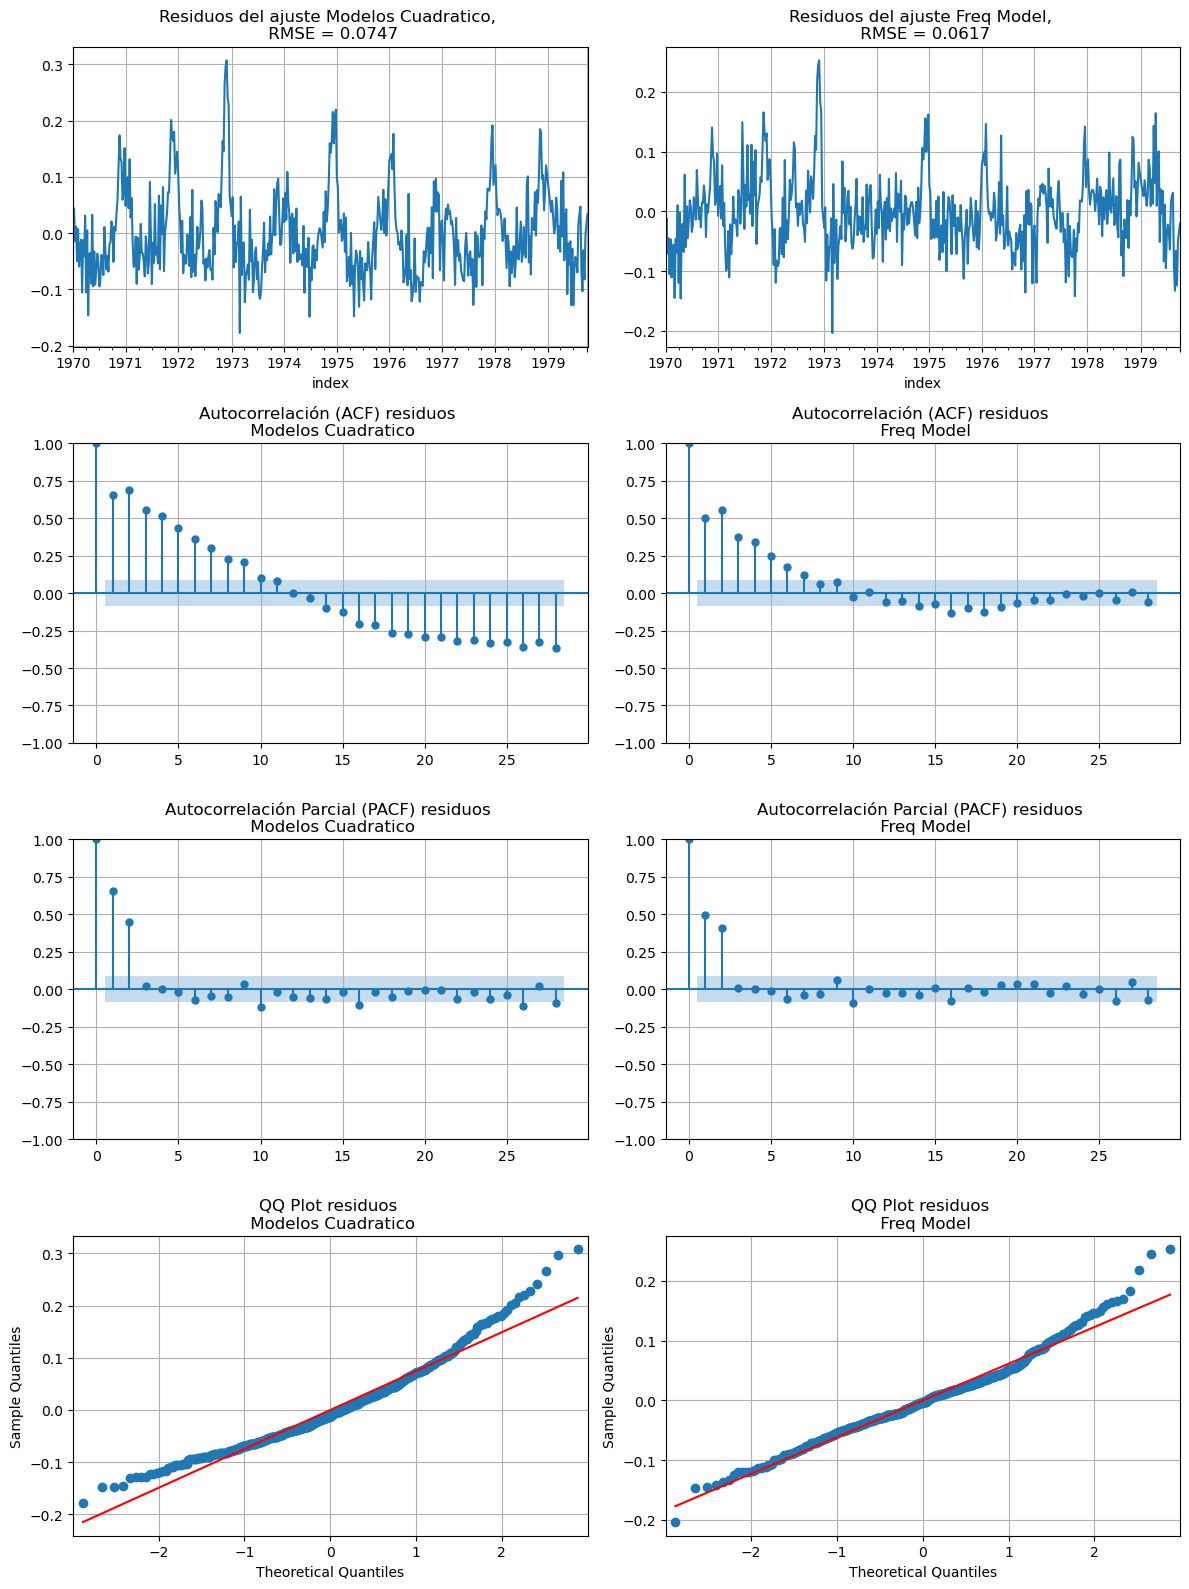

In [79]:
plot_fits([fit_quad,fit_freq],[quad_mse,freq_mse],["Modelos Cuadratico","Freq Model"])

parece mejorar mucho la curve agregando una componente de frecuencia en 0.019685. Baja mucho el RMSE, y aunque sube el AIC y BIC, el tradeoff parece valerlo.

Y ademas en el QQ plot vemos como los residuos se acercan mucho mas a un modelo de ruido blanco gaussiano

Lo que puede observarse tambien es que aun quedan componentes en el ACF y PACF que pueden contener informacion importante. 

Basicamnete en ambos hay 2 componentes con correlacion muy alta antes de decaer y bajar de forma paulatina.

Por eso vamos a probar con un modelo SARIMAX de orden 2,0,1, incluyendo las componentes de frecuencia estudiadas

In [74]:
x_df = pd.DataFrame({
    "time": time,
    "time2":time**2,
    "cos": np.cos(2*np.pi*f*time),
    "sin": np.sin(2*np.pi*f*time)
})
x_df = sm.add_constant(x_df)


In [75]:
modelo = SARIMAX(
    log_x,
    exog=x_df,
    order=(2,0,1)
)

fit_mod = modelo.fit()
mod_mse=np.sqrt(fit_mod.mse)
print(f"RMSE de los residuos: {mod_mse}")
fit_mod.summary()

RMSE de los residuos: 0.048544221125959124


/Users/juancruz/miniconda3/envs/series/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                  tmort   No. Observations:                  508
Model:               SARIMAX(2, 0, 1)   Log Likelihood                 815.893
Date:                Mon, 13 Jul 2026   AIC                          -1613.786
Time:                        07:34:11   BIC                          -1575.712
Sample:                    01-04-1970   HQIC                         -1598.856
                         - 10-07-1979                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          5.2059      0.023    230.583      0.000       5.162       5.250
time          -0.0006      0.000     -2.734      0.006      -0.001      -0.000
time2       7.376e-07   3.82e-07      1.931      0.054   -1.12e-08    1.49e-06
cos            0.0564      0.009      6.126      0.000       0.038       0.074
sin            0.0193      0.010      2.006      0.045       0.000       0.038
ar.L1          0.3206      0.103      3.122      0.002       0.119       0.522
ar.L2          0.3957      0.065      6.118      0.000       0.269       0.522
ma.L1         -0.0312      0.109     -0.287      0.774      -0.244       0.182
sigma2         0.0024      0.000     16.832      0.000       0.002       0.003
===================================================================================
Ljung-Box (L1) (Q):                   0.00   Jarque-Bera (JB):                 2.71
Prob(Q):                              0.98   Prob(JB):                         0.26
Heteroskedasticity (H):               0.81   Skew:                            -0.00
Prob(H) (two-sided):                  0.17   Kurtosis:                         3.36
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

/var/folders/zc/xfn7bz2d1wj_vv2lvqvmndcr0000gp/T/ipykernel_23787/831404204.py:27: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


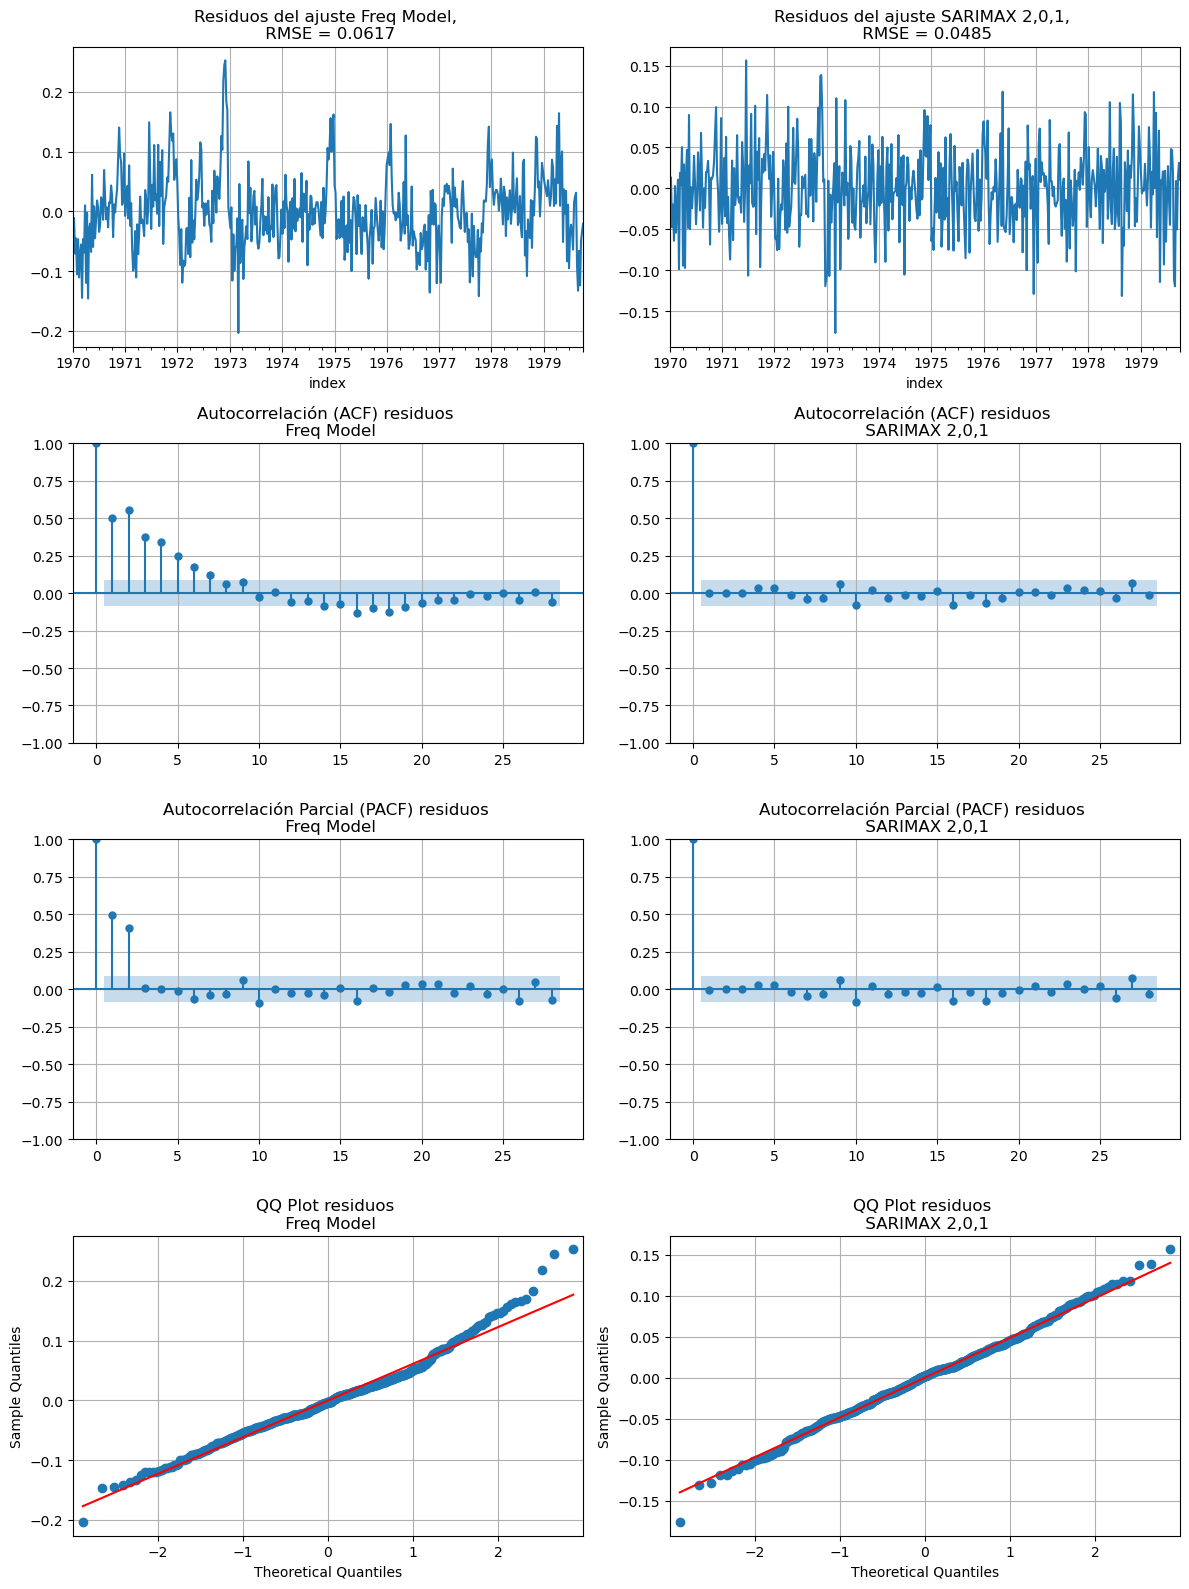

In [80]:
plot_fits([fit_freq, fit_mod],[freq_mse, mod_mse],["Freq Model", "SARIMAX 2,0,1"])

## Ejercicio 2

Se considera la serie del producto interno bruto de EEUU medido trimestralmente.

1. Realizar una transformación de tipo $\nabla \log()$ para calcular el incremento porcentual aproximado.
2. Discutir brevemente si la serie resultante es estacionaria y si está o no centrada en 0.
3. Realizar un análisis de la autocorrelación y autocorrelación parcial.
4. Realizar un ajuste a un modelo $ARMA(p,q)$ adecuado. Puede incorporar dos modelos para comparar.
5. Analizar los residuos resultantes.
6. Realizar una predicción para el año siguiente.

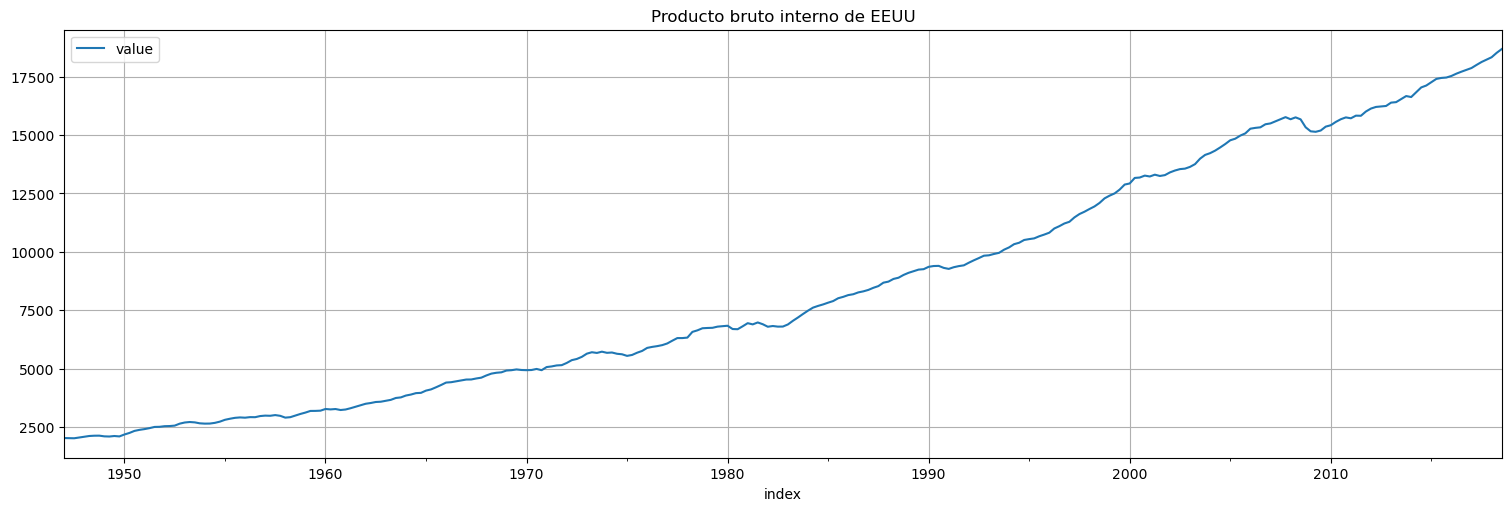

In [183]:
x=astsa.gdp
x.plot();
plt.title("Producto bruto interno de EEUU");

#### 1.

<Axes: xlabel='index'>

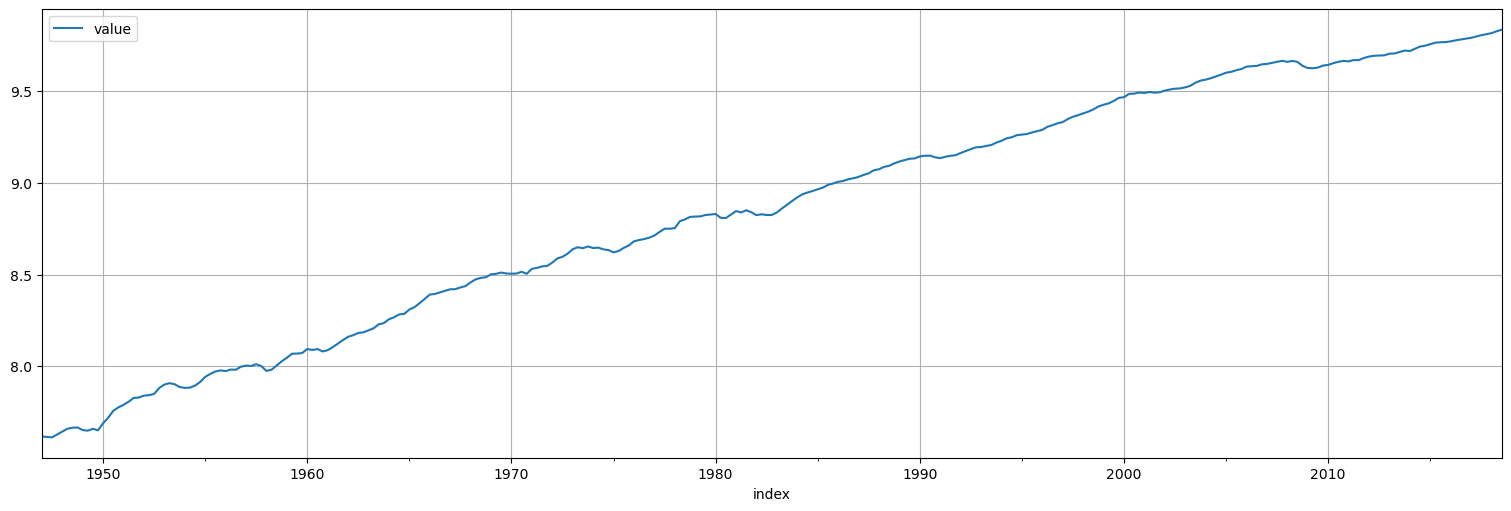

In [184]:
x_log=np.log(x)
x_log.plot()

#### 2.

La serie parece estacionaria en un primer momento, puesto que presenta una tendecia creciente constante, pero no parece estar centrada en 0

#### 3. 

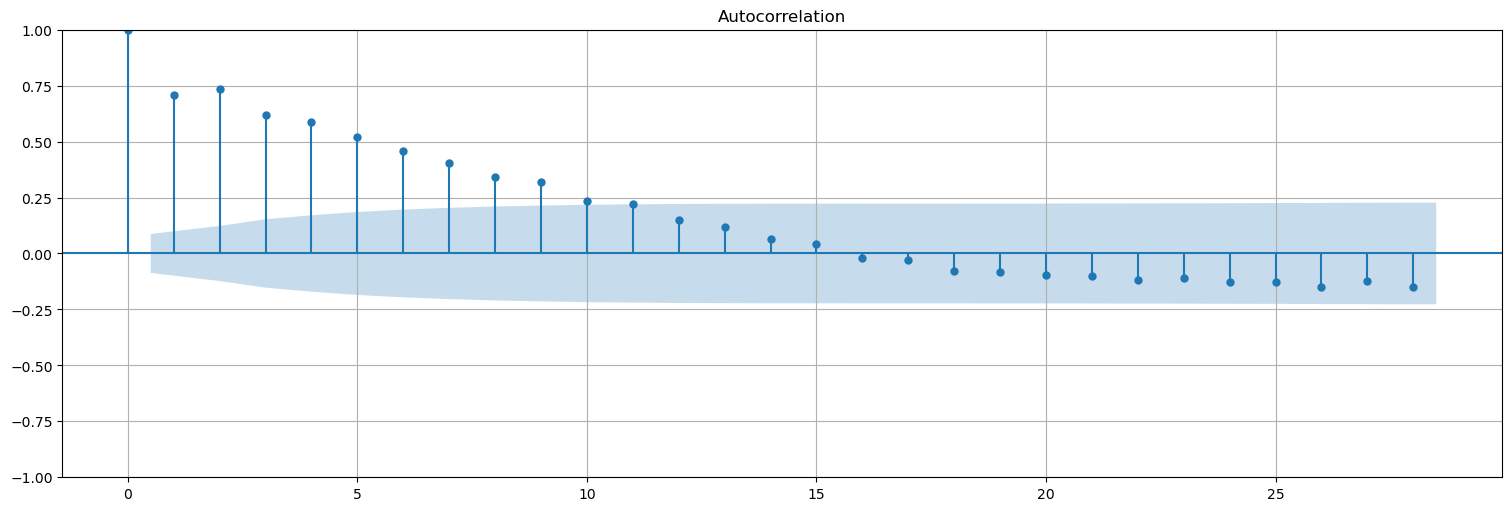

In [185]:
plot_acf(log_x);

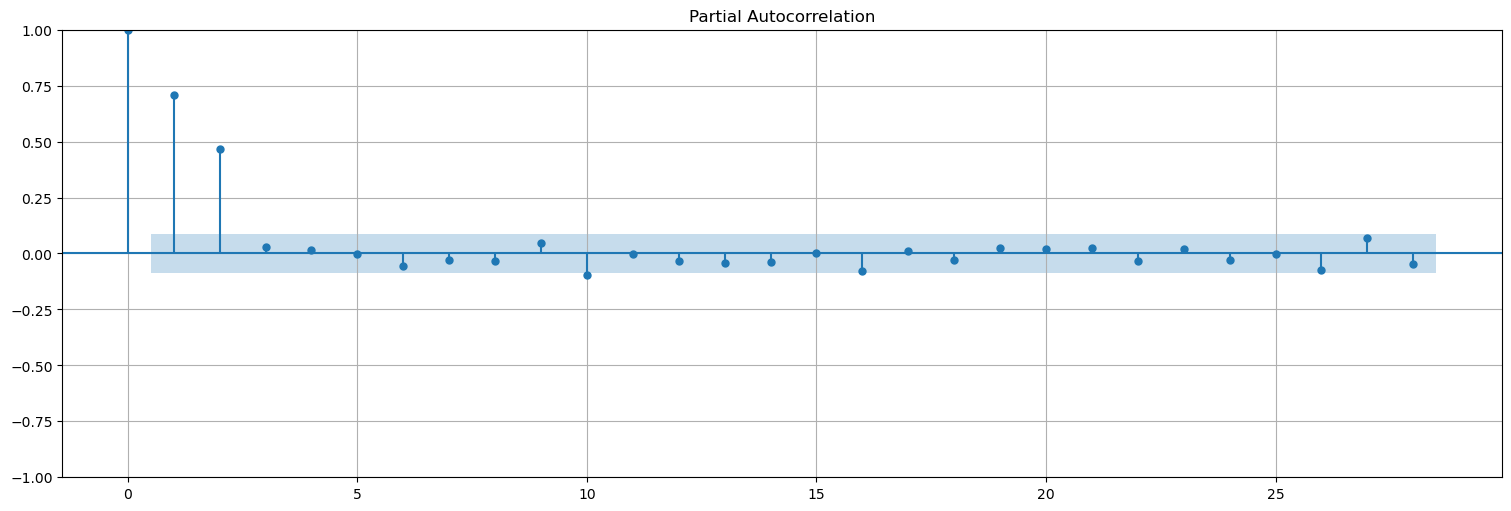

In [149]:
plot_pacf(log_x);

#### 4.

In [186]:
fit1 = ARIMA(log_x,order=(0,0,2), trend="c").fit()
mse1=np.sqrt(fit1.mse)
print(f"MSE del modelo ARIMA(0,0,2): {mse1}")
fit1.summary()

MSE del modelo ARIMA(0,0,2): 0.05909363239367629


<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                  tmort   No. Observations:                  508
Model:                 ARIMA(0, 0, 2)   Log Likelihood                 716.266
Date:                Mon, 13 Jul 2026   AIC                          -1424.532
Time:                        08:27:06   BIC                          -1407.611
Sample:                    01-04-1970   HQIC                         -1417.897
                         - 10-07-1979                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          5.1270      0.005    984.970      0.000       5.117       5.137
ma.L1          0.4323      0.038     11.509      0.000       0.359       0.506
ma.L2          0.5042      0.035     14.399      0.000       0.436       0.573
sigma2         0.0035      0.000     16.588      0.000       0.003       0.004
===================================================================================
Ljung-Box (L1) (Q):                  13.39   Jarque-Bera (JB):                 4.58
Prob(Q):                              0.00   Prob(JB):                         0.10
Heteroskedasticity (H):               0.77   Skew:                             0.20
Prob(H) (two-sided):                  0.09   Kurtosis:                         3.23
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [187]:
fit2 = ARIMA(log_x,order=(1,0,2), trend="c").fit()
mse2=np.sqrt(fit2.mse)
print(f"MSE del modelo ARIMA(2,0,2): {mse2}")
fit2.summary()

MSE del modelo ARIMA(2,0,2): 0.05070396094291831


<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                  tmort   No. Observations:                  508
Model:                 ARIMA(1, 0, 2)   Log Likelihood                 794.318
Date:                Mon, 13 Jul 2026   AIC                          -1578.637
Time:                        08:27:09   BIC                          -1557.485
Sample:                    01-04-1970   HQIC                         -1570.342
                         - 10-07-1979                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          5.1287      0.014    354.744      0.000       5.100       5.157
ar.L1          0.8939      0.023     39.093      0.000       0.849       0.939
ma.L1         -0.5279      0.045    -11.790      0.000      -0.616      -0.440
ma.L2          0.2082      0.048      4.350      0.000       0.114       0.302
sigma2         0.0026      0.000     16.026      0.000       0.002       0.003
===================================================================================
Ljung-Box (L1) (Q):                   0.09   Jarque-Bera (JB):                 0.35
Prob(Q):                              0.77   Prob(JB):                         0.84
Heteroskedasticity (H):               0.79   Skew:                            -0.06
Prob(H) (two-sided):                  0.13   Kurtosis:                         3.04
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

/var/folders/zc/xfn7bz2d1wj_vv2lvqvmndcr0000gp/T/ipykernel_23787/831404204.py:27: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


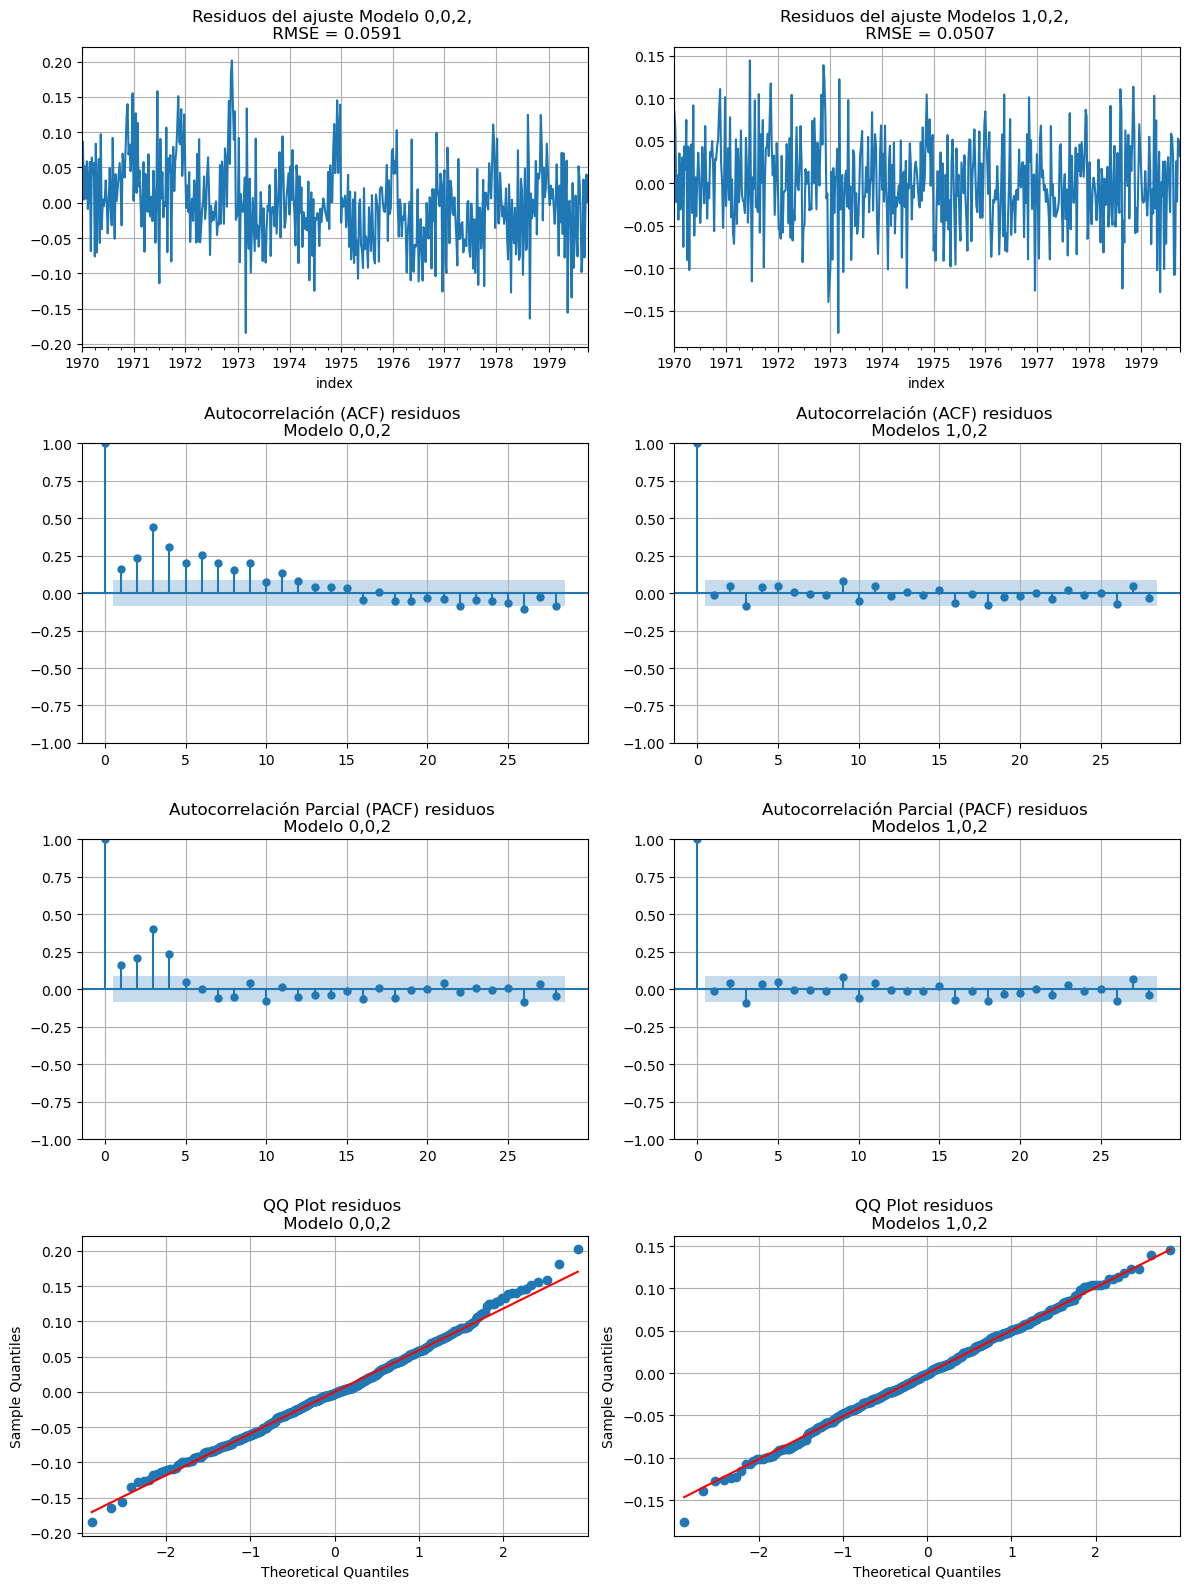

In [188]:
plot_fits([fit1,fit2],[mse1,mse2],["Modelo 0,0,2","Modelos 1,0,2"])

In [189]:
# 1. Obtenemos el objeto de predicción para los próximos 12 períodos
predicciones_futuras = fit2.get_forecast(steps=12)

# 2. Extraemos la predicción media y los intervalos (aún en escala logarítmica)
xhat_log = predicciones_futuras.predicted_mean
confint_log = predicciones_futuras.conf_int(alpha=0.05)

# 3. Exponenciamos para volver a la escala original de la serie
xhat1 = np.exp(xhat_log)
confint1 = np.exp(confint_log)



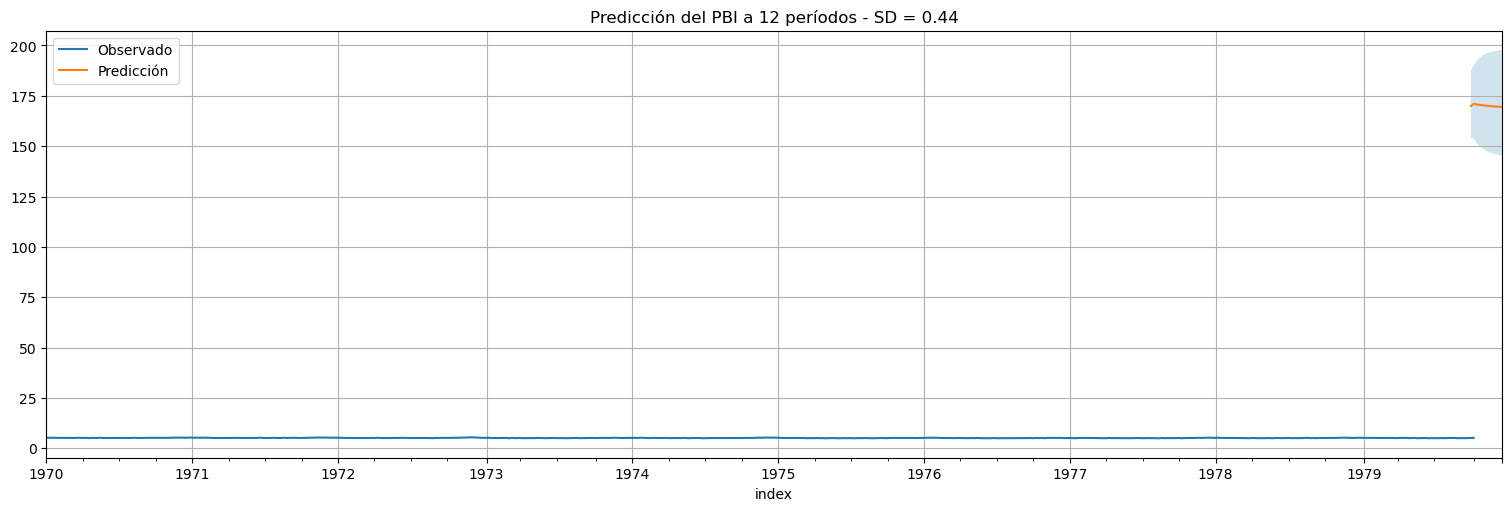

In [191]:
# Graficamos primero la serie original para la leyenda "Observado"
observado = fit2.data.orig_endog
observado.plot()
# Graficamos la predicción
xhat1.plot()
# Leyenda
plt.legend(["Observado", "Predicción"])
# Sombreado del intervalo de confianza
plt.fill_between(
    xhat1.index, 
    confint1.iloc[:, 0],  # Límite inferior (equivalente a "lower value")
    confint1.iloc[:, 1],  # Límite superior (equivalente a "upper value")
    alpha=0.2
)
# Título adaptado (sin RMSE porque estamos prediciendo el futuro desconocido)
plt.title(f"Predicción del PBI a 12 períodos - SD = {np.std(xhat1):.2f}")
plt.show()

## Ejercicio 3

Se considera la serie de $x$ de crecimiento relativo (calculado como $\nabla \log (z)$) del consumo privado en la economía de EEUU y la serie análoga $y$ de crecimiento relativo del desempleo.

1. Analice la correlación cruzada entre ambas series.
2. ¿Para que valor de lag se da la mayor correlación entre ambas?
3. Se propone un modelo de la forma $y_t = \beta_0 + \beta_1 x_{t-l} + w_t$ con $x$ e $y$ como antes y $l$ el lag de la parte anterior. Realice un ajuste lineal para estimar los parámetros $\beta_0$ y $\beta_1$.
4. ¿Cuánto de la varianza de la serie original se explica por la relación entre $x$ e $y$?
5. Realice un gráfico de la predicción del modelo (no olvide que la primera predicción será luego de $l$ lags) y el crecimiento relativo del desempleo observado. 
6. Analice los residuos del modelo y discuta si aún queda información por ajustar.

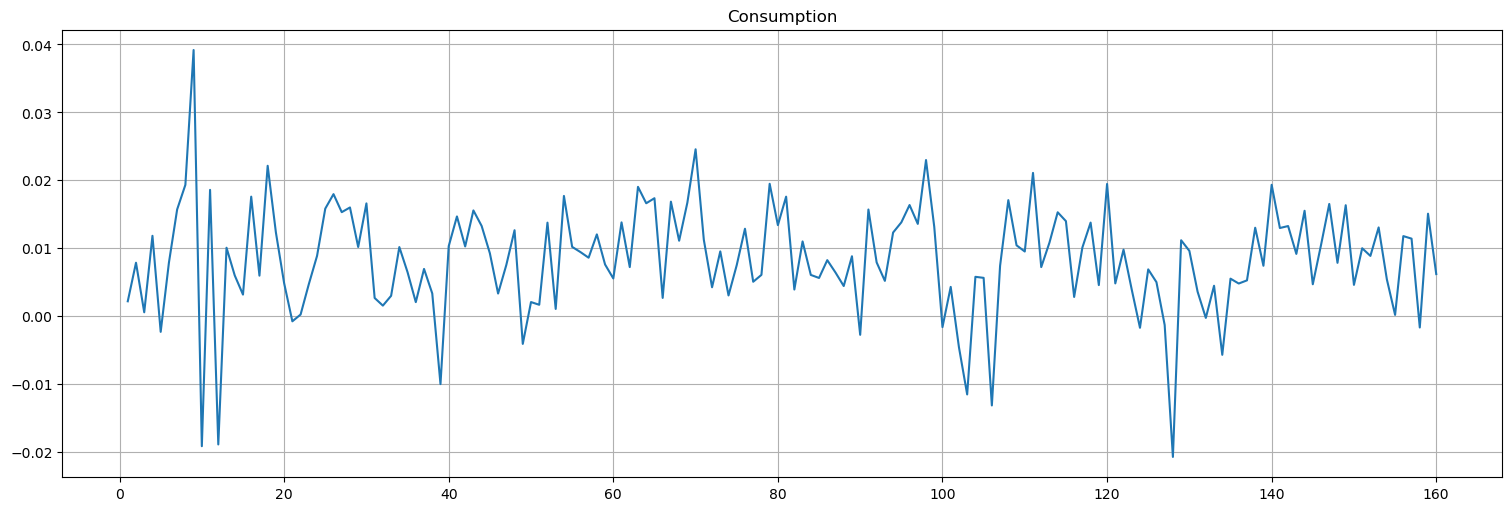

In [155]:
x=np.log(astsa.econ5["consum"]).diff()
y=np.log(astsa.econ5["unemp"]).diff()
x.plot();
plt.title("Consumption");

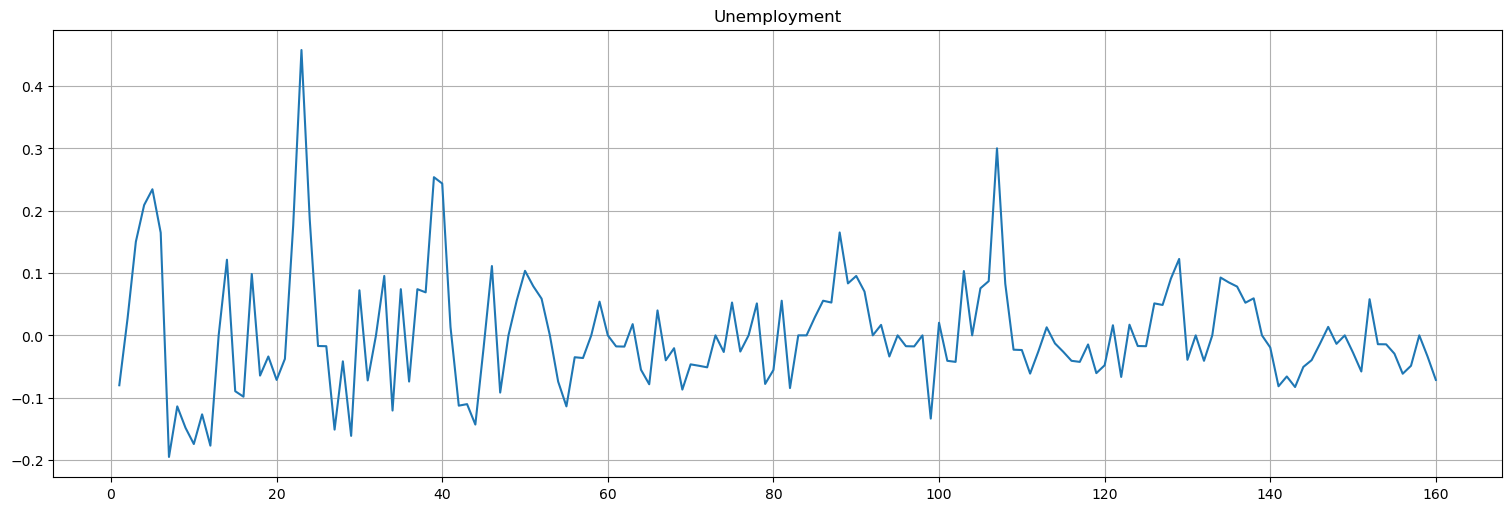

In [156]:
y.plot();
plt.title("Unemployment");

In [157]:
x = x.diff().dropna()
y = y.diff().dropna()

<Axes: xlabel='LAG', ylabel='CCF'>

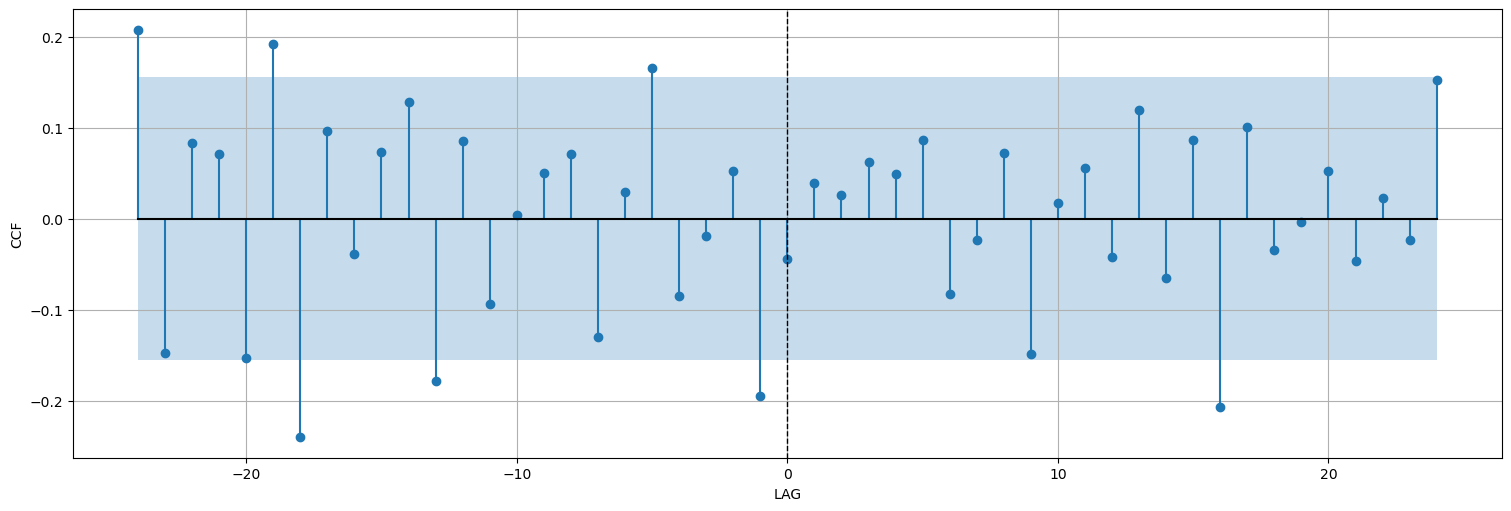

In [158]:
ccf(x, y, max_lag=24)

Parece haber una correlacion en lag 1 y quizas lag 5, donde x shift 1 y shift 5 explica y.

In [192]:

reg_df = pd.concat([x, x.shift(1),x.shift(5),y], axis=1).dropna()
reg_df.columns = ["x","xlag1", "xlag5", "y"]

fit = ols("y ~ x+ xlag1 + xlag5 + 0", data=reg_df).fit()
print(f"RMSE de los residuos: {np.sqrt(fit.mse_resid)}")
fit.summary()

ValueError: zero-size array to reduction operation maximum which has no identity